In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score)

from imblearn.over_sampling import SMOTE

# modeling
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# EDA

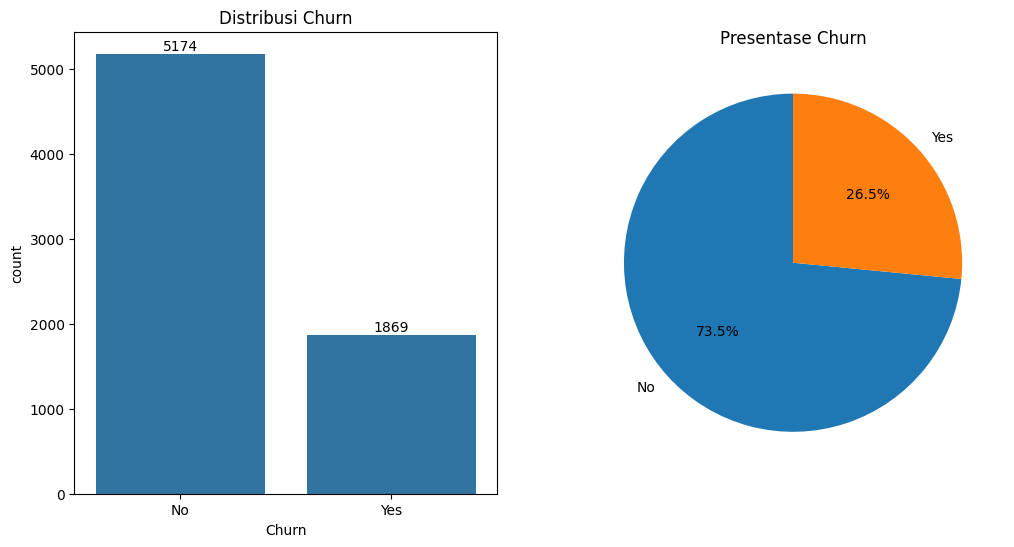

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Distribusi Churn dan presentasenya 
ax = sns.countplot(data=df, x='Churn', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Distribusi Churn')

count_churn = df['Churn'].value_counts()
axes[1].pie(count_churn, labels=count_churn.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Presentase Churn')

plt.show()

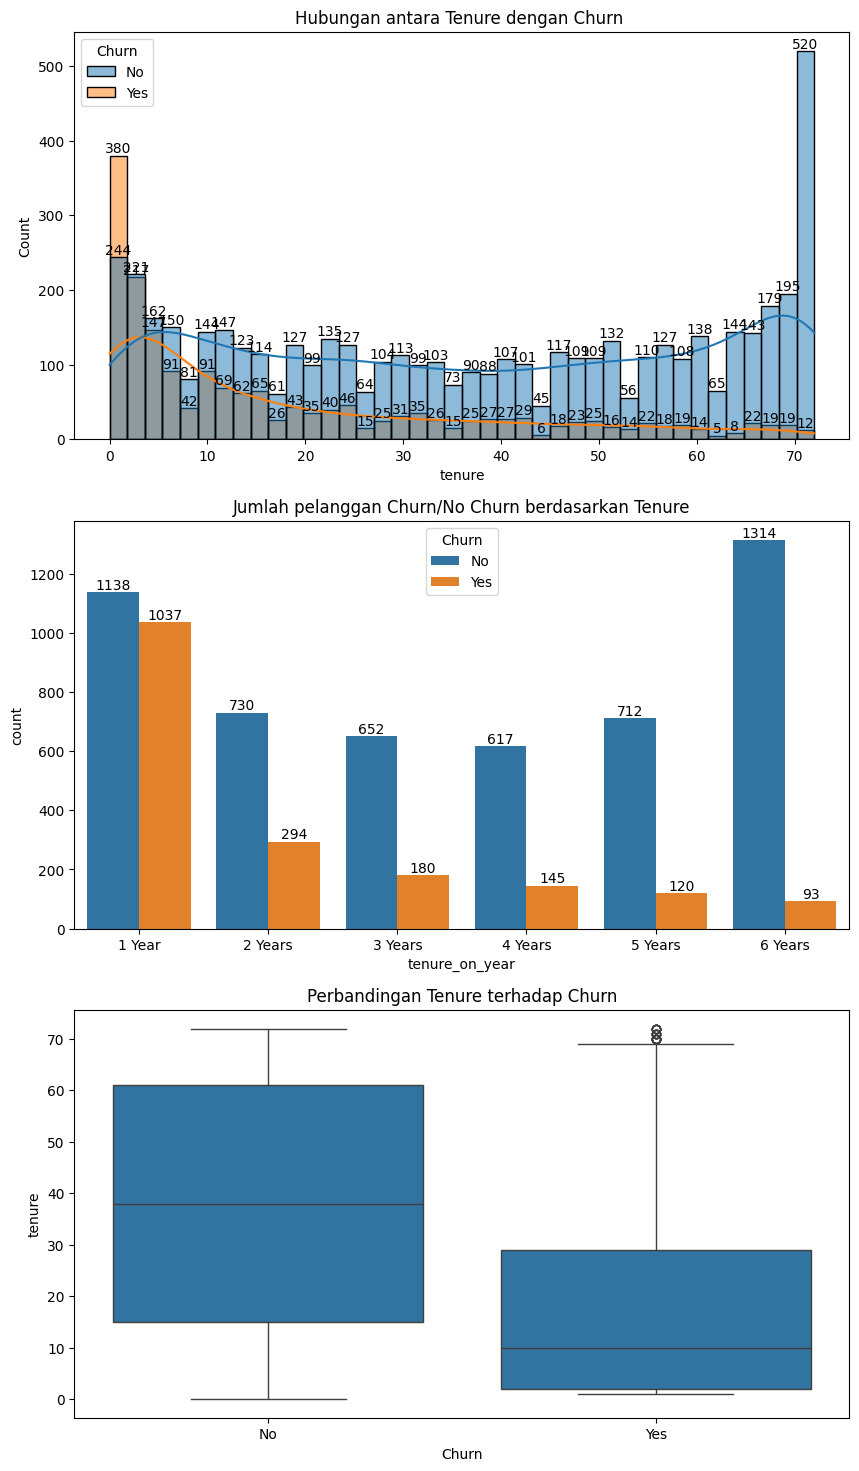

In [6]:
# hubungan tenure(lama berlangganan) dengan churn
fig, axes = plt.subplots(3,1, figsize=(10, 18))

# tenure vs churn
sns.histplot(data=df, x='tenure', hue='Churn', bins=40, kde=True, ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Hubungan antara Tenure dengan Churn ')

# melihat jumlah banyaknya pelanggan churn atau tidak dalam tahunan
df['tenure_on_year'] = pd.cut(df['tenure'], bins=(0,12,24,36,48,60,72),
                           labels=['1 Year','2 Years','3 Years','4 Years','5 Years','6 Years'])
sns.countplot(data=df, x='tenure_on_year', hue='Churn',ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Jumlah pelanggan Churn/No Churn berdasarkan Tenure')

# hubungan tenure dengan chuen dalam bentuk boxplot=
sns.boxplot(data=df, x='Churn', y='tenure')
axes[2].set_title('Perbandingan Tenure terhadap Churn')

plt.show()

Visualisasi menunjukkan bahwa pelanggan dengan tenure rendah (awal berlangganan) memiliki jumlah churn yang jauh lebih tinggi dibandingkan pelanggan dengan tenure yang lebih lama. Hal ini terlihat baik dari distribusi maupun agregasi per tahun, di mana churn paling banyak terjadi pada tahun pertama dan terus menurun seiring bertambahnya lama berlangganan. Pola ini mengindikasikan bahwa pelanggan baru merupakan kelompok yang paling rentan untuk berhenti.

Boxplot juga memperkuat temuan tersebut, di mana median tenure pelanggan yang churn jauh lebih rendah dibandingkan yang tidak churn. Pelanggan yang tidak churn cenderung memiliki tenure yang lebih tinggi dan distribusi yang lebih luas, menunjukkan tingkat loyalitas yang lebih kuat. Dengan demikian, dapat disimpulkan bahwa tenure merupakan faktor penting dalam churn, di mana semakin lama pelanggan berlangganan, semakin kecil kemungkinan mereka untuk berhenti.

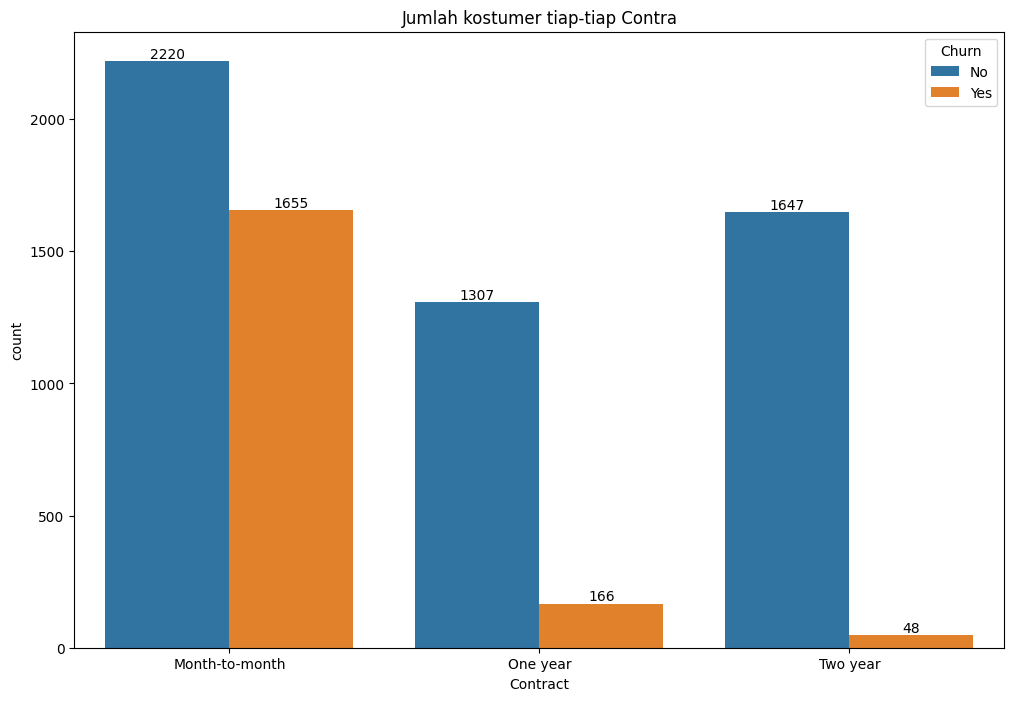

In [7]:
# Contrac dengan Churn
# biasana kalo contraknya dalam tahunan kemungkinan besar Churnnya kecil

plt.figure(figsize=(12,8))
ax=sns.countplot(data=df, x='Contract', hue='Churn')
for i in ax.containers:
    ax.bar_label(i)
plt.title('Jumlah kostumer tiap-tiap Contra')
plt.show()

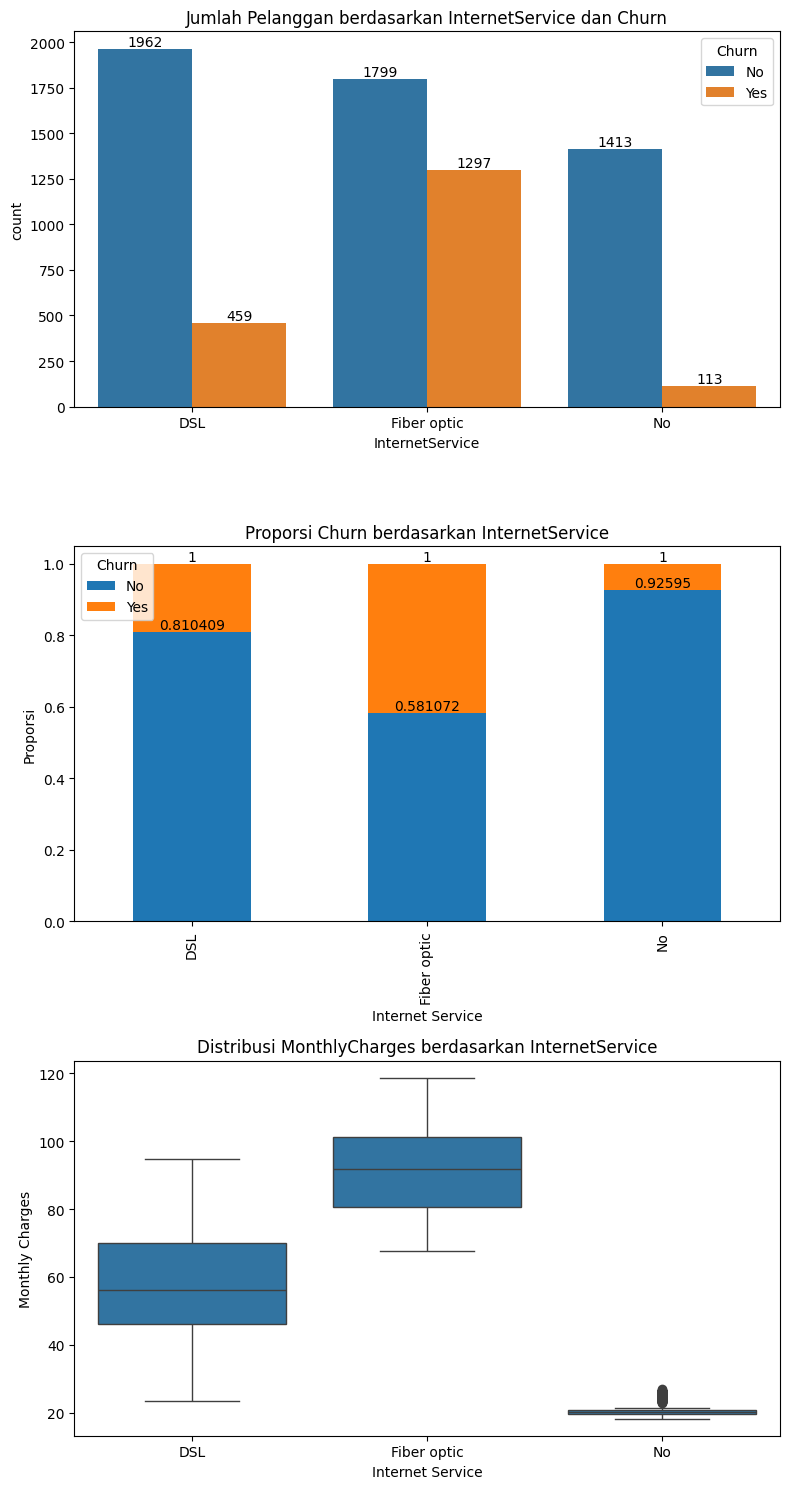

In [8]:
# Visualisasi InternetService

# countplot
fig, axes = plt.subplots(3,1, figsize=(8,15))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)
axes[0].set_title('Jumlah Pelanggan berdasarkan InternetService dan Churn')

# Proporsi Churn
ct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
ct.plot(kind='bar', stacked=True, ax=axes[1])
for i in axes[1].containers:
    axes[1].bar_label(i)
axes[1].set_title('Proporsi Churn berdasarkan InternetService')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Proporsi')

#  boxplot MonthlyCharges
sns.boxplot(data=df, x='InternetService', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Distribusi MonthlyCharges berdasarkan InternetService')
axes[2].set_xlabel('Internet Service')
axes[2].set_ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

Visualisasi menunjukkan bahwa pelanggan dengan layanan Fiber optic memiliki jumlah dan proporsi churn yang paling tinggi dibandingkan DSL dan tanpa internet. Meskipun jumlah pelanggan Fiber optic cukup besar, tingkat churn-nya juga signifikan, yang mengindikasikan bahwa segmen ini lebih rentan untuk berhenti berlangganan. Sebaliknya, pelanggan tanpa internet memiliki tingkat churn paling rendah, menunjukkan kecenderungan yang lebih stabil.

Dari sisi biaya, boxplot memperlihatkan bahwa Fiber optic memiliki MonthlyCharges paling tinggi, diikuti DSL, dan terendah pada pelanggan tanpa internet. Hal ini menguatkan indikasi bahwa biaya layanan yang lebih tinggi dapat menjadi faktor pendorong churn, terutama pada pengguna Fiber optic yang kemungkinan memiliki ekspektasi layanan lebih tinggi.

In [9]:
# # MonthlyCharges dan TotalCharges dengan Churn 
# fig, axes = plt.subplots(1,2, figsize=(12,8))

# # MonthlyCharges vs Churn
# sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0])
# axes[0].set_title('Hubungan MonthlyCharges dengan Churn')

# # TotalCharges vs Churn
# sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1])
# axes[1].set_title('Hubungan TotalCharges dengan Churn')

# plt.tight_layout()
# plt.show()

In [10]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

Visualisasi menunjukkan bahwa pada MonthlyCharges, pelanggan yang melakukan churn memiliki median biaya yang lebih tinggi dibandingkan pelanggan yang tidak churn. Hal ini mengindikasikan bahwa biaya bulanan yang besar berpotensi meningkatkan kemungkinan pelanggan untuk berhenti berlangganan. Sementara itu, pada TotalCharges, pola yang terlihat belum memberikan perbedaan yang jelas antara kelompok churn dan non-churn, sehingga interpretasinya masih terbatas dan belum dapat dijadikan dasar kesimpulan yang kuat.

Perlu diperhatikan bahwa variabel TotalCharges masih bertipe object (string), sehingga visualisasi yang dihasilkan belum sepenuhnya merepresentasikan kondisi data yang sebenarnya, nanti akan dilakukan penyesuaian ketika preprocessing

In [11]:
# # Visualisasi semua jenis layanan yang ada
# fig, axes = plt.subplots(2, 3, figsize=(15,10))
# features = ['OnlineSecurity','OnlineBackup','DeviceProtection',
#             'TechSupport','StreamingTV','StreamingMovies']

# # fitur total services
# df['TotalServices'] = df[features].apply(lambda x: (x == 'Yes').sum(), axis=1)

# # proporsi Churn untuk tiap fitur
# for i, col in enumerate(features):
#     row = i // 3
#     col_idx = i % 3
    
#     ct = pd.crosstab(df[col], df['Churn'], normalize='index')
#     ct.plot(kind='bar', stacked=True, ax=axes[row, col_idx], legend=False)
    
#     axes[row, col_idx].set_title(f'{col}')
#     axes[row, col_idx].set_ylabel('Proporsi')
#     axes[row, col_idx].set_xlabel('')
#     axes[row, col_idx].tick_params(axis='x', rotation=20)

# plt.tight_layout()
# plt.show()

In [12]:
# # Analisis Pengaruh Jumlah Layanan terhadap Churn
# plt.figure(figsize=(8,5))

# df['TotalServices'] = df[features].apply(lambda x: (x == 'Yes').sum(), axis=1)
# sns.set_style("whitegrid")
# sns.countplot(x='TotalServices', hue='Churn', data=df)

# plt.title('Jumlah Layanan terhadap Churn')
# plt.xlabel('Jumlah Layanan (TotalServices)')

# plt.tight_layout()
# plt.show()

# PREPROCESSING

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [14]:
# kita hapus terlebih dahulu featur yang tidak relevan 

# hapus customerID dan tenure_on_year
df.drop(columns=['customerID', 'tenure_on_year'], inplace=True)

# kita ubah TotalCharges karena masih str padahal di dataset dia float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [15]:
# kita buat variabel data frame baru
df_clean = df.copy()
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Cek missing value dan duplicate value

In [16]:
# missing value
df_clean.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
df_clean.dropna(subset=['TotalCharges'], inplace=True)
df_clean.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
# duplicate data
df_clean.duplicated().sum()

np.int64(22)

In [19]:
df_clean.drop_duplicates(inplace=True)
df_clean.duplicated().sum()

np.int64(0)

In [20]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  MonthlyChar

# Feature Encoder

## LabelEncoder

In [21]:
# ubah data "No internet service" menjadi No 
jenis_layanan = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for i in jenis_layanan:
    df_clean[i] = df_clean[i].replace('No internet service', 'No')

# ubah data "No phone service" menjadi "No"
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# ubah data dari gender mejadi 0 dan 1

In [22]:
binary_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines',
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

le = LabelEncoder()
for i in binary_cols:
    df_clean[i] = le.fit_transform(df_clean[i])

Nilai kategori seperti "No internet service" dan "No phone service" terlebih dahulu diseragamkan menjadi "No" untuk mengurangi redundansi dan memastikan konsistensi data, kemudian seluruh variabel biner (misalnya Yes/No dan Male/Female) ditransformasikan ke representasi numerik (0 dan 1) menggunakan Label Encoding

## Ordinal Encoding

In [23]:
# Mengubah data menjadi numerik yang memiliki urutan menggunakan Ordinal Encoding
df_clean['Contract'] = df_clean['Contract'].map({
    'Month-to-month' : 0,
    'One year' : 1,
    'Two year' : 2
})

## OneHotEncoding

In [24]:
# karena tidk punya urutan nilai data jadi gunakan OneHotEncoding
multi_cols = [
    'InternetService',
    'PaymentMethod'
]

df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

Fitur 'Contract' dikonversi menggunakan ordinal encoding karena memiliki urutan yang jelas berdasarkan tingkat komitmen pelanggan (dari bulanan hingga kontrak jangka panjang), sehingga representasi numerik dapat menangkap hubungan tersebut. Sementara itu, fitur seperti 'InternetService' dan 'PaymentMethod' menggunakan one-hot encoding karena bersifat nominal (tidak memiliki urutan), sehingga setiap kategori direpresentasikan secara independen untuk menghindari asumsi hubungan linear yang tidak sesuai. Penggunaan drop_first=True bertujuan mengurangi redundansi fitur dan mencegah multikolinearitas pada model linear.

In [25]:
df_clean.head(20)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,0,1,29.85,29.85,0,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,1,0,56.95,1889.50,0,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,0,1,53.85,108.15,1,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,1,0,42.30,1840.75,0,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,0,1,70.70,151.65,1,True,False,False,True,False
5,0,0,0,0,8,1,1,0,0,1,...,0,1,99.65,820.50,1,True,False,False,True,False
6,1,0,0,1,22,1,1,0,1,0,...,0,1,89.10,1949.40,0,True,False,True,False,False
7,0,0,0,0,10,0,0,1,0,0,...,0,0,29.75,301.90,0,False,False,False,False,True
8,0,0,1,0,28,1,1,0,0,1,...,0,1,104.80,3046.05,1,True,False,False,True,False
9,1,0,0,1,62,1,0,1,1,0,...,1,0,56.15,3487.95,0,False,False,False,False,False


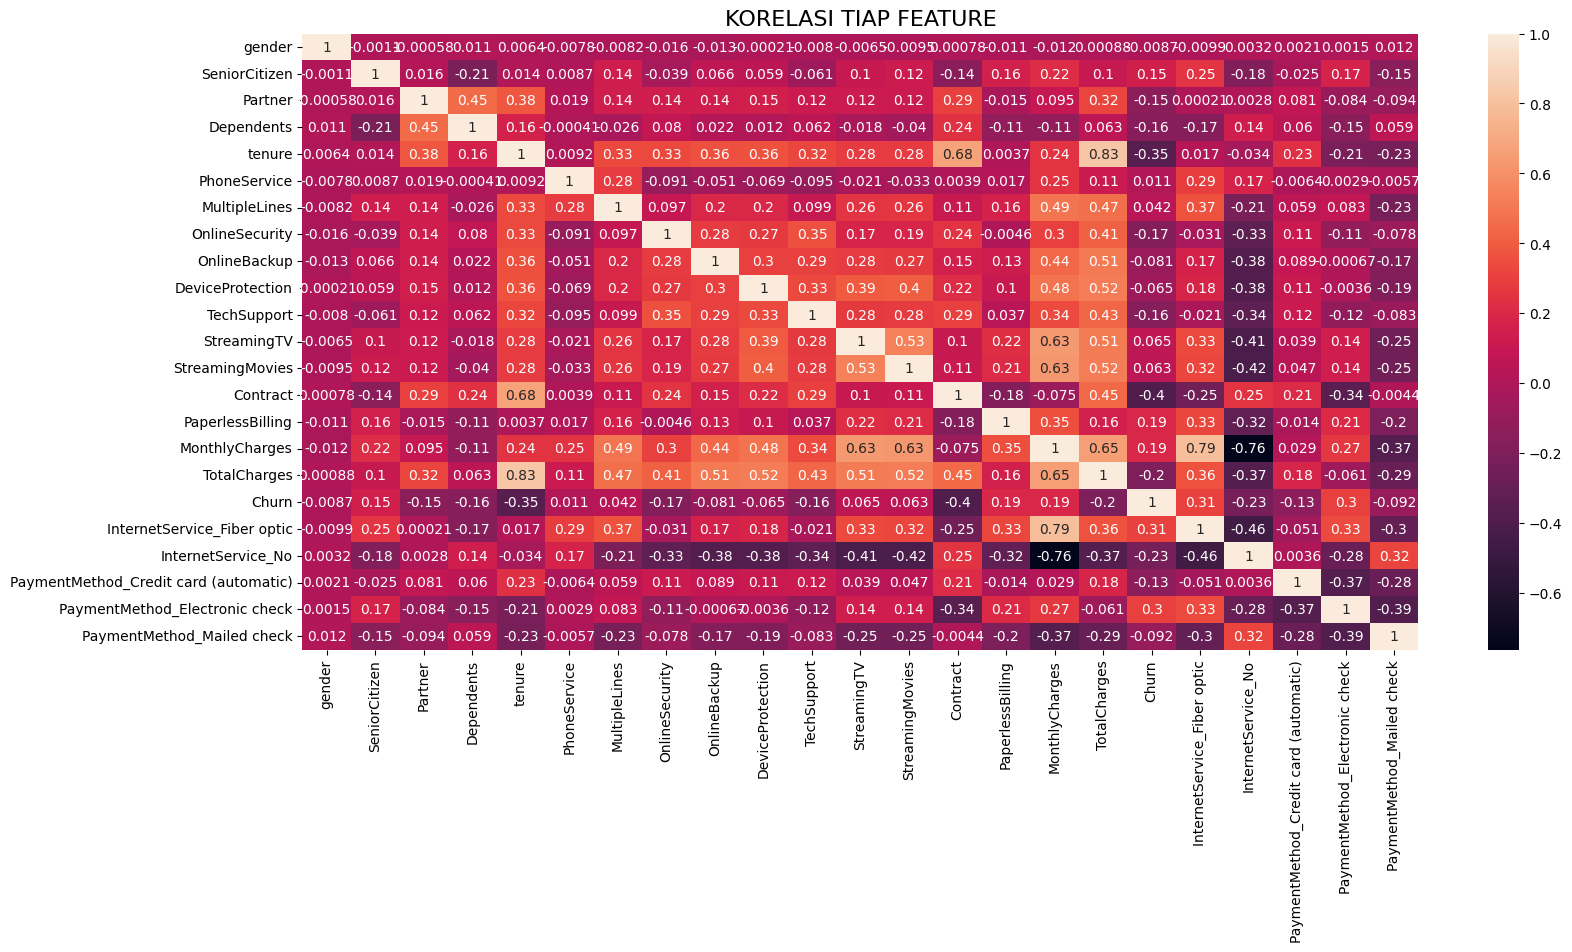

In [26]:
# Korelasi dari data yang sudah bersih
plt.figure(figsize=(18,8))

heat_cor = df_clean.corr()
sns.heatmap(data=heat_cor, annot=True)

plt.title('KORELASI TIAP FEATURE',fontsize=16)
plt.show()

# Split data

In [27]:
X = df_clean.drop(columns='Churn')
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
print(list(X_train.columns))
print(y_train.name)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Churn


# Normalisasi

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE 

In [40]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Sebelum SMOTE")
print(y_train.value_counts())
print("Setelah SMOTE")
print(y_train_smote.value_counts())

Sebelum SMOTE
Churn
0    4122
1    1486
Name: count, dtype: int64
Setelah SMOTE
Churn
0    4122
1    4122
Name: count, dtype: int64


Disini pada feature target itu mengalami imbalanced data, jadi digunaakn teknik SMOTE utk mengatasi imbalanced data tersebut agar dataya sama rata

# LightGBM modeling

In [52]:
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=12,
    num_leaves=31,
    random_state=42
)

lgbm.fit(
    X_train_smote, y_train_smote
)

[LightGBM] [Info] Number of positive: 4122, number of negative: 4122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2125
[LightGBM] [Info] Number of data points in the train set: 8244, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
# evaluasi modelnya
y_pred = model.predict(X_test_scaled)

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(conf_matrix)
print(conf_matrix)
print(conf_matrix)

[LightGBM] [Warning] Unknown parameter: n_estimator
